In [14]:
import numpy as np
import matplotlib.pyplot as plt
import jax.random as jrd
import jax.numpy as jnp
from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.landscape_visuals import *
from jax_test import pytree_to_landscape
from jax_test.regimes import mr_const
from jax_test.dynamics import get_cell_states
from jax_test.losses import origin_leading_fitness, biseparating_fitness
from jax_test.experiment import run_experiment
from jax.scipy.special import kl_div, entr
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Landscape with one regime + simple visualization
%autoreload

# Definition of the modules of the landscape: to be constructed accordingly

M1 = Node(x=-1.5, y=0., a=1.5, s=1.)
M2 = Node(x=3., y=0., a=2., s=0.8)

module_list = [M1, M2]


# M1 = Node(x=-3., y=0., a=3., s=1.)
# M2 = Node(x=4., y=0., a=3., s=1.)
# M3 = Node (x= 2., y= 3., a= 3.,s=1.)

# module_list = [M1, M2,M3]

for M in module_list:
    print(M)

# Definition of the landscape
landscape = Landscape(module_list, A0 = 0.01, regime=mr_const, n_regimes=1)
print(landscape)

# key used for noise
key = jrd.PRNGKey(0)

#Numerical constants for simulation
n, cell_noise, t0,tf, nt, ndt, noise, η, iterations=200, 0.5, 0., 10., 51, 50, 0.5, 0.001, 700

# Selection of the get_states function 
get_states = get_cell_states

# Selection of the fitness function
loss_function = biseparating_fitness

T, λ, q_prob =1., 10., (0.5,0.5)

loss_param = T, λ, q_prob

# For signal regime
signal_param = None

Node: x=-1.5; y=0.0; a=1.5; s=1.
Node: x=3.0; y=0.0; a=2.; s=0.8
Landscape with modules:
Node: x=-1.5; y=0.0; a=1.5; s=1.,
Node: x=3.0; y=0.0; a=2.; s=0.8


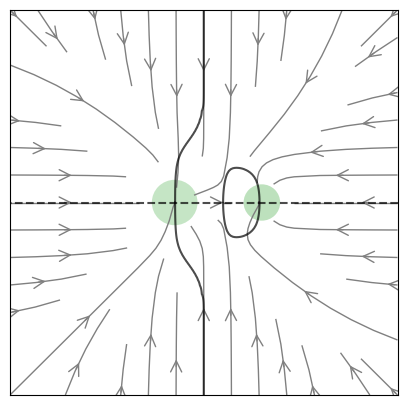

In [16]:
# Parameters of vizualisation 
L = 10.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

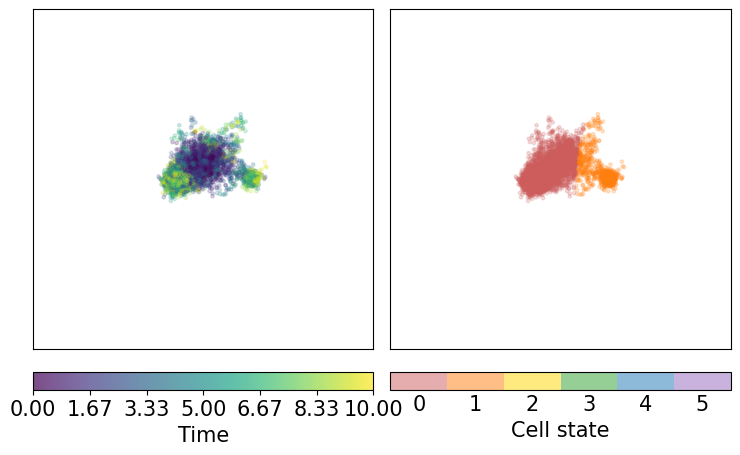

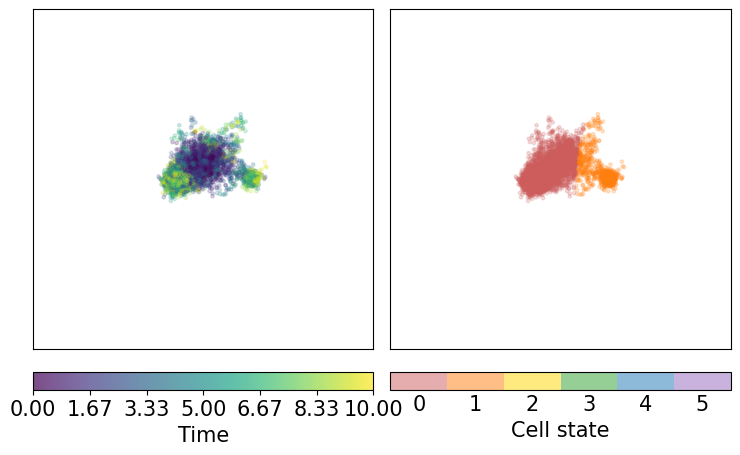

In [17]:
landscape.init_cells(n,landscape.init_cond,noise=noise)
get_and_plot_traj(landscape,t0,tf,nt,L,noise)

In [18]:
# n_frames = 100
# time_pars = (t0,tf, n_frames)
# print(landscape.n_regimes)
# labels = [f"regime {i}" for i in range(0,landscape.n_regimes+1)]
# print(labels)
# make_movie_discrete(landscape, xx, yy, labels, time_pars, n, noise, init_cond=landscape.init_cond,
#                         circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
#                         fps=10, save_dir='../figures/', filename='start_traj.gif')

# save_dir = '../figures/'
# import os, glob
# for f in glob.glob(save_dir + "frame_*.png"):
#     os.remove(f)

In [19]:
dynamic, static, losses, traj, states= run_experiment(
    landscape,
    key,
    n,
    cell_noise,
    t0,
    tf,
    nt,
    ndt,
    noise,
    iterations,
    η,
    get_states,
    loss_function,
    loss_param,
    signal_param
    )


In [20]:
print(dynamic)

LandscapeDynamic(init_cond=Array([0.16833927, 1.0129788 ], dtype=float32), module=ModuleDynamic(x=Array([-1.5840049,  2.913076 ], dtype=float32), y=Array([-0.0548736,  0.0409785], dtype=float32), a=Array([1.4544369, 2.0275505], dtype=float32), s=Array([1.03646  , 1.2895104], dtype=float32)))


In [21]:
print(jnp.mean(states[:,-1]))

0.48


In [22]:
final_coord = traj[:,:,-1]

module_coord = jnp.stack((dynamic.module.x,dynamic.module.y))
m = module_coord.shape[1]
dist_squared = jnp.sum((final_coord.T[:, :, None] - module_coord)**2, axis=1)

weights = jnp.exp(-jnp.sqrt(dist_squared) / T)

P = weights / (jnp.sum(weights, axis=1, keepdims=True) + 1e-8)

p_j = jnp.mean(P, axis=0)

loss_uniform = jnp.sum(kl_div(p_j,jnp.array(q_prob))+kl_div(jnp.array(q_prob),p_j))

print(P[:5,:])

[[0.01892764 0.98107237]
 [0.98727304 0.01272695]
 [0.02316593 0.9768341 ]
 [0.01182348 0.9881765 ]
 [0.9880759  0.01192403]]


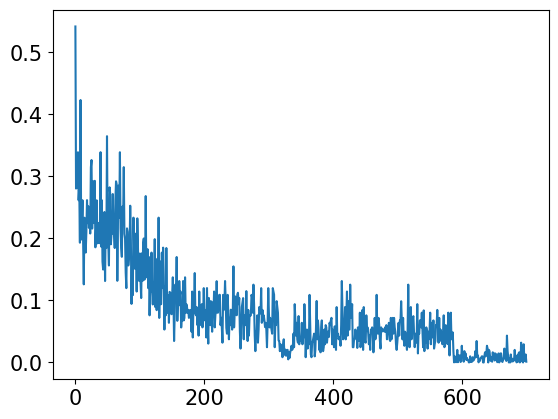

In [23]:
plt.plot(losses)

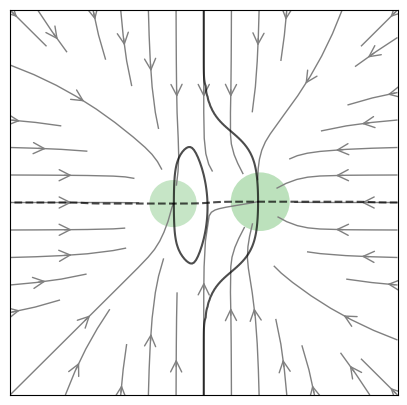

In [24]:
l = pytree_to_landscape(dynamic=dynamic,static=static,trajectories=np.array(traj), cell_states= np.array(states), cell_coordinates= np.array(traj[:,:,-1]))
fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')

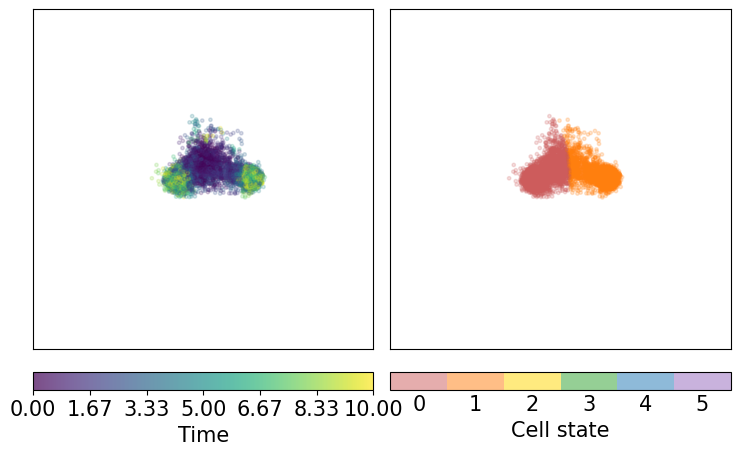

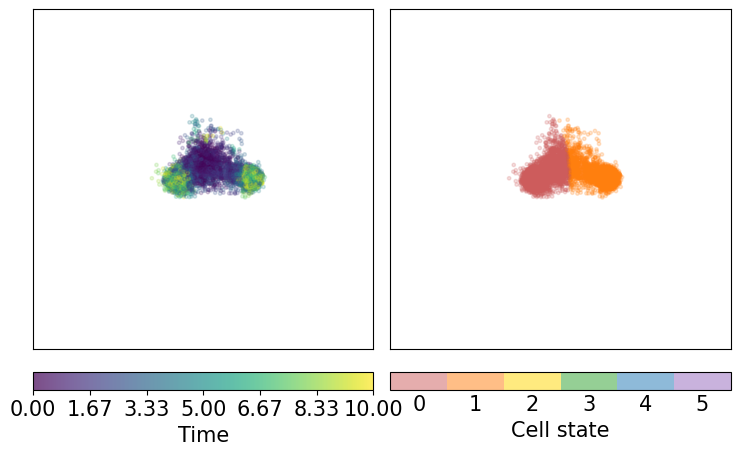

In [25]:
# Put back the coordinates of the cells at the init_ as the are
l.init_cells(n,dynamic.init_cond,noise=noise)
get_and_plot_traj(l,t0,tf,nt,L,noise)

In [26]:
n_frames = 100
time_pars = (t0,tf, n_frames)
print(l.n_regimes)
labels = [f"regime {i}" for i in range(0,l.n_regimes+1)]
print(labels)
make_movie_discrete(l, xx, yy, labels, time_pars, n, noise, init_cond=l.init_cond,
                        circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
                        fps=10, save_dir='../figures/', filename='end_traj.gif')

save_dir = '../figures/'
import os, glob
for f in glob.glob(save_dir + "frame_*.png"):
    os.remove(f)

1
['regime 0', 'regime 1']
Movie saved to ../figures/end_traj.gif
